# 02 Exploratory Data Analysis


In [1]:
!pip install pandas matplotlib seaborn openpyxl


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import os
import glob
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

root_path = Path(os.getcwd()).parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path / "src"))

from utils import TAG_INFO, THRESHOLDS

In [3]:
""" Import the complete dataset """

df = pd.read_excel('../data/raw/data_11-03_10-04.xlsx', sheet_name='Sheet1')

# Change the starting point of our data. Start where we data from all features
df["timestamp"]     = pd.to_datetime(df["timestamp"])
df                  = df.sort_values("timestamp").reset_index(drop=True)
first_complete_idx  = df.notna().all(axis=1).idxmax()
df_complete         = df.iloc[first_complete_idx:].reset_index(drop=True)

In [4]:
""" Import the subdatasets """

path = "../data/processed/data_11-03_10-04/clean"
all_files = glob.glob(os.path.join(path, "*.csv"))
dict_sessions = {}

for file in all_files:
    file_name = os.path.basename(file)
    session_id = int(file_name.split('_')[2])

    # Read the CSV make sure our index is the timestamp
    df = pd.read_csv(file, index_col='timestamp', parse_dates=True)
    dict_sessions[session_id] = df
sorted_keys = sorted(dict_sessions.keys())

print(f"Session IDs: {sorted_keys}")


Session IDs: [1, 2, 3, 5, 8, 12, 13, 14, 15, 16, 17]


In [5]:
continuous_cols = ["PT-901", "PT-902", "PT-903",
                   "TT-901", "TT-902", "TT-903", "TT-904",
                   "FT-201", "FT-801", "FT-901",
                   "VSD-901_CORRENT", "VSD-901_POWER", "VSD-901_RPM", "VSD-901_SPEED"]

summary = df_complete[continuous_cols].describe().T
summary.columns = ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
summary["unit"] = [TAG_INFO[col]["unit"] for col in summary.index]
summary["label"] = [TAG_INFO[col]["label"] for col in summary.index]
summary = summary[["label", "unit", "count", "mean", "std", "min", "25%", "50%", "75%", "max"]]

summary

,label,unit,count,mean,std,min,25%,50%,75%,max
PT-901,Gas line inlet vacuum pressure,bar,39175.0,-0.681261,0.248792,-1.025101e+00,-0.833261,-0.721137,-0.551866,0.088325
PT-902,Gas line outlet vacuum pressure,bar,39175.0,0.014293,0.011896,-1.381654e-02,0.006221,0.011357,0.020399,0.050564
PT-903,Vacuum pressure in oil separator,bar,39175.0,0.066029,0.265176,-2.896296e+00,0.049769,0.081481,0.126389,0.259375
TT-901,Oil separator gas temperature,°C,39175.0,67.057679,5.048644,1.839193e+01,64.708115,67.485893,69.954422,77.083336
TT-902,Discharge 1 temperature,°C,39175.0,68.251732,4.955964,1.911893e+01,65.950523,68.630646,71.093750,78.114151
TT-903,Discharge 2 temperature,°C,39175.0,77.238675,5.234921,2.142470e+01,74.631073,77.696396,80.183918,88.395187
TT-904,Oil temperature,°C,39175.0,77.012884,5.493264,1.836480e+01,74.571396,77.468536,79.937065,87.917747
FT-201,Biogas inlet flow,Nm3/h,39175.0,621.789320,160.074010,-1.506076e+01,597.092041,652.126770,718.815094,826.258728
FT-801,Biomethane outlet flow,Nm3/h,39175.0,308.181333,87.328342,-8.000000e+02,303.588867,328.637695,352.563477,760.180603
FT-901,Exhaust gas flow,Nm3/h,39175.0,307.039863,235.333878,2.246094e+00,159.293617,266.699219,434.977219,929.003906


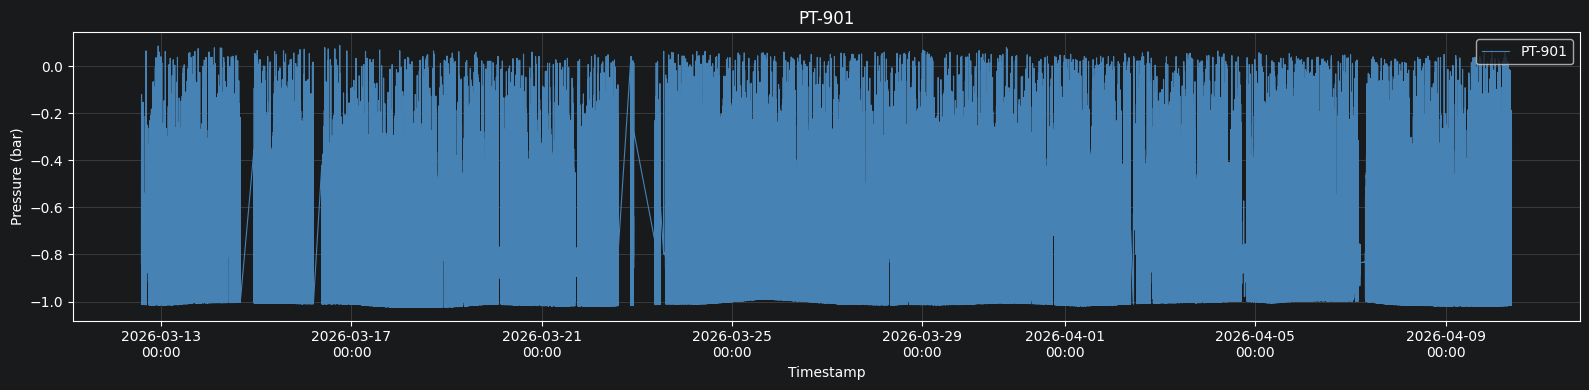

In [10]:
""" Univariate Time Series — PT-901 """

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["PT-901"],
    linewidth=0.8,
    color="steelblue",
    label="PT-901"
)

ax.set_title("PT-901")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Pressure (bar)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


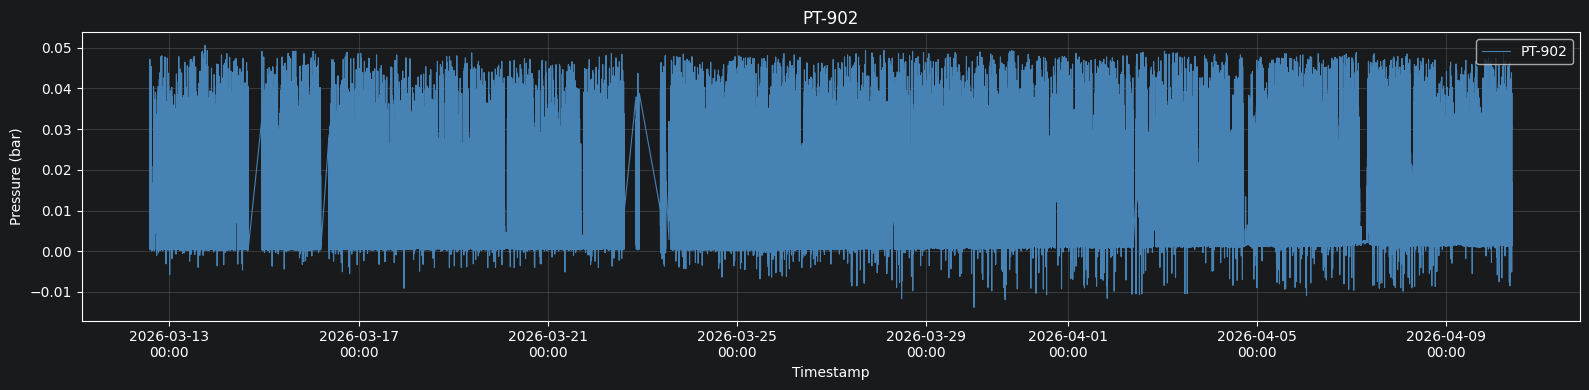

In [11]:
""" Univariate Time Series — PT-902 """

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["PT-902"],
    linewidth=0.8,
    color="steelblue",
    label="PT-902"
)

ax.set_title("PT-902")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Pressure (bar)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


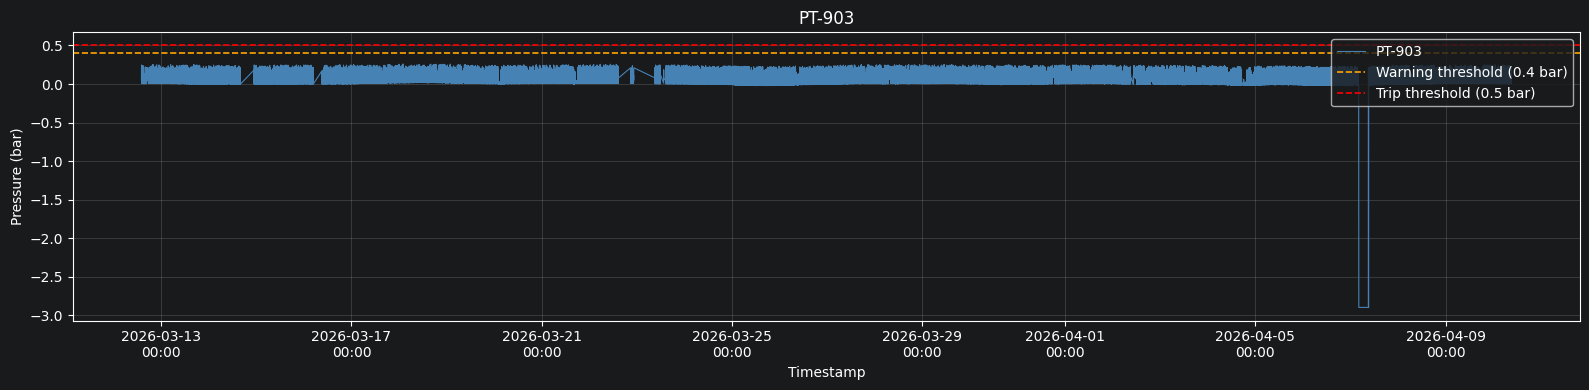

In [12]:
""" Univariate Time Series — PT-903 """

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["PT-903"],
    linewidth=0.8,
    color="steelblue",
    label="PT-903"
)

ax.axhline(
    y=THRESHOLDS["PT-903"]["warning"],
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Warning threshold ({THRESHOLDS['PT-903']['warning']} bar)"
)

ax.axhline(
    y=THRESHOLDS["PT-903"]["trip"],
    color="red",
    linewidth=1.2,
    linestyle="--",
    label=f"Trip threshold ({THRESHOLDS['PT-903']['trip']} bar)"
)

ax.set_title("PT-903")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Pressure (bar)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()